In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/loan_data_with_risk.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,RiskCategory,LoanToIncomeRatio,AssetToLiabilityRatio
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,Medium Risk,0.329228,7.616692
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,Medium Risk,0.655897,5.544971
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,Medium Risk,0.432841,0.195354
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,Medium Risk,0.548579,19.519926
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,Low Risk,0.088937,14.133114


In [3]:
print(df.dtypes.value_counts())
print("\nText columns:")
print(df.select_dtypes(include="object").columns.tolist())

int64      21
float64    11
str         7
Name: count, dtype: int64

Text columns:
['ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskCategory']


C:\Users\pattn\AppData\Local\Temp\ipykernel_13260\200751894.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


In [4]:
df_model = df.drop(columns=["ApplicationDate"])

df_model = pd.get_dummies(df_model, columns=[
    "EmploymentStatus", "EducationLevel", "MaritalStatus",
    "HomeOwnershipStatus", "LoanPurpose", "RiskCategory"
], drop_first=True)

print(df_model.shape)
df_model.head()

(20000, 50)


,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Widowed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,RiskCategory_Low Risk,RiskCategory_Medium Risk
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,False,False,True,False,False,False,True,False,False,True
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,False,False,False,False,True,False,False,False,False,True
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,False,False,False,True,False,True,False,False,False,True
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,False,False,False,False,False,False,True,False,False,True
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,False,False,False,False,True,False,False,False,True,False


In [5]:
X = df_model.drop(columns=["LoanApproved", "RiskScore"])
y = df_model["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

NameError: name 'train_test_split' is not defined

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [7]:
X = df_model.drop(columns=["LoanApproved", "RiskScore"])
y = df_model["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (16000, 48)
Test set: (4000, 48)


In [8]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.88975
Precision: 0.7126341866226259
Recall: 0.9027196652719666
F1 Score: 0.7964928472542686


c:\Users\pattn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.98925
Precision: 0.9682051282051282
Recall: 0.9874476987447699
F1 Score: 0.9777317452097359


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.98925
Precision: 0.9682051282051282
Recall: 0.9874476987447699
F1 Score: 0.9777317452097359


In [11]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.98025
Precision: 0.961093585699264
Recall: 0.9560669456066946
F1 Score: 0.9585736759307814


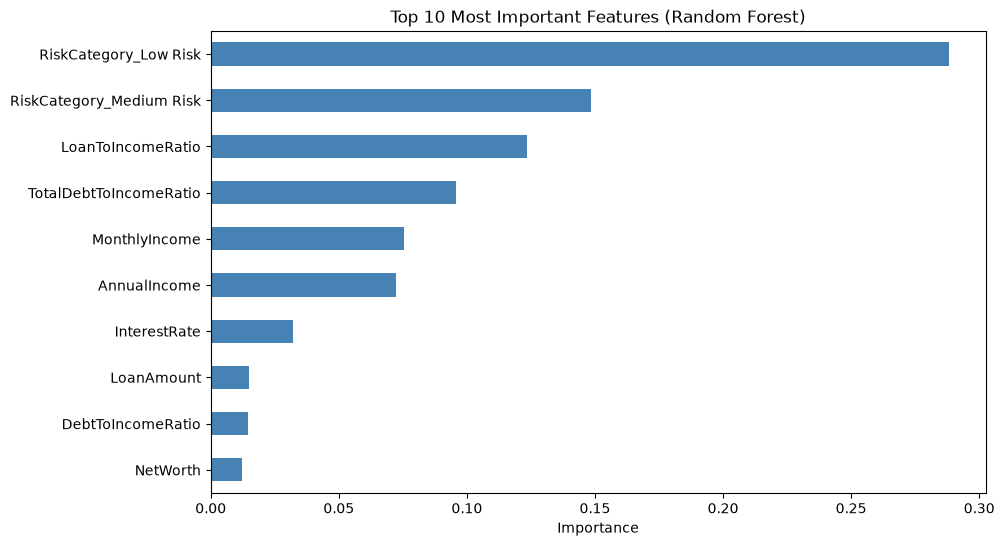

In [12]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_features.plot(kind="barh", color="steelblue")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [13]:
X_test_with_predictions = X_test.copy()
X_test_with_predictions["Actual_LoanApproved"] = y_test.values
X_test_with_predictions["Predicted_LoanApproved"] = y_pred  # from Logistic Regression

X_test_with_predictions.to_csv("../data/processed/model_predictions.csv", index=False)
print("Saved!")

Saved!


In [14]:
import pandas as pd
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importances)

NameError: name 'model' is not defined

In [15]:
import pandas as pd

df = pd.read_csv('Loan_data.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Loan_data.csv'

In [16]:
import pandas as pd

df = pd.read_excel(r'C:\Users\pattn\OneDrive\Desktop\Bank-Loan-Risk-Analytics\data\processed\loan_data_with_risk.xlsx')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\pattn\\OneDrive\\Desktop\\Bank-Loan-Risk-Analytics\\data\\processed\\loan_data_with_risk.xlsx'

In [17]:
import pandas as pd

df = pd.read_csv(r'C:\Users\pattn\OneDrive\Desktop\Bank-Loan-Risk-Analytics\data\processed\loan_data_with_risk.csv')
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,RiskCategory,LoanToIncomeRatio,AssetToLiabilityRatio
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,Medium Risk,0.329228,7.616692
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,Medium Risk,0.655897,5.544971
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,Medium Risk,0.432841,0.195354
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,Medium Risk,0.548579,19.519926
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,Low Risk,0.088937,14.133114


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

# Keep only numeric columns (drop text columns like ApplicationDate, EmploymentStatus, etc.)
X = X.select_dtypes(include=['int64', 'float64'])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances.head(10))

                   Feature  Importance
28               RiskScore    0.419157
27  TotalDebtToIncomeRatio    0.118731
29       LoanToIncomeRatio    0.111733
20           MonthlyIncome    0.081292
1             AnnualIncome    0.065959
25            InterestRate    0.037940
23                NetWorth    0.018515
4               LoanAmount    0.017746
18             TotalAssets    0.014628
24        BaseInterestRate    0.012197
